In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("chinook.db")

In [8]:
query1 = """
SELECT 
    g.name AS genre,
    COUNT(t.track_id) AS track_count
FROM genre g
JOIN track t ON g.genre_id = t.genre_id
GROUP BY g.genre_id, g.name
ORDER BY track_count DESC
LIMIT 10;
"""

df1 = pd.read_sql_query(query1, conn)

df1

,genre,track_count
0,Rock,1297
1,Latin,579
2,Metal,374
3,Alternative & Punk,332
4,Jazz,130
5,TV Shows,93
6,Blues,81
7,Classical,74
8,Drama,64
9,R&B/Soul,61


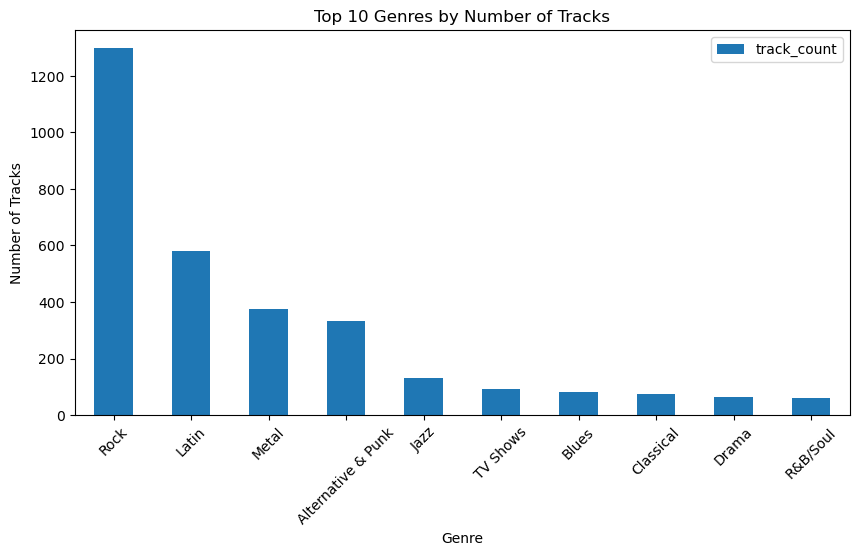

In [9]:
df1.plot(
    x="genre",
    y="track_count",
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Genres by Number of Tracks"
)

plt.xlabel("Genre")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=45)
plt.show()

In [10]:
query2 = """
SELECT 
    a.title AS album,
    COUNT(t.track_id) AS track_count
FROM album a
JOIN track t ON a.album_id = t.album_id
GROUP BY a.album_id, a.title
ORDER BY track_count DESC
LIMIT 10;
"""

df2 = pd.read_sql_query(query2, conn)

df2

,album,track_count
0,Greatest Hits,57
1,Minha Historia,34
2,Unplugged,30
3,"Lost, Season 3",26
4,"Lost, Season 1",25
5,"The Office, Season 3",25
6,My Way: The Best Of Frank Sinatra [Disc 1],24
7,"Lost, Season 2",24
8,"Battlestar Galactica (Classic), Season 1",24
9,Afrociberdelia,23


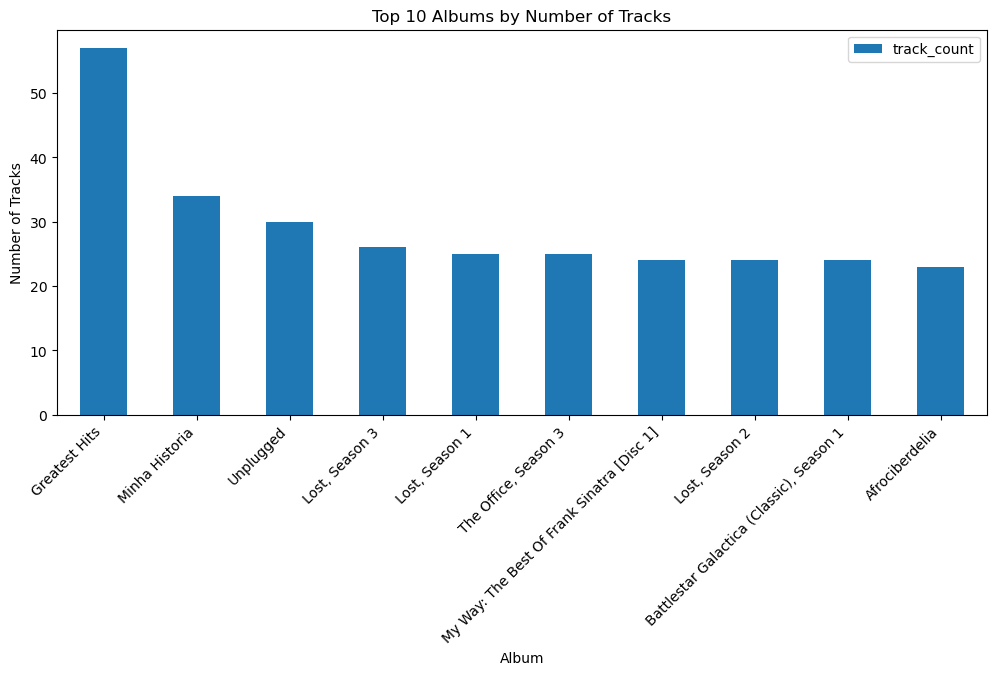

In [11]:
df2.plot(
    x="album",
    y="track_count",
    kind="bar",
    figsize=(12, 5),
    title="Top 10 Albums by Number of Tracks"
)

plt.xlabel("Album")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=45, ha="right")
plt.show()

In [12]:
query3 = """
SELECT 
    c.customer_id,
    c.first_name || ' ' || c.last_name AS customer,
    SUM(i.total) AS total_spent
FROM customer c
JOIN invoice i ON c.customer_id = i.customer_id
GROUP BY c.customer_id
ORDER BY total_spent DESC
LIMIT 10;
"""

df3 = pd.read_sql_query(query3, conn)

df3

,customer_id,customer,total_spent
0,5,František Wichterlová,144.54
1,6,Helena Holý,128.70
2,46,Hugh O'Reilly,114.84
3,58,Manoj Pareek,111.87
4,1,Luís Gonçalves,108.90
5,13,Fernanda Ramos,106.92
6,34,João Fernandes,102.96
7,3,François Tremblay,99.99
8,42,Wyatt Girard,99.99
9,17,Jack Smith,98.01


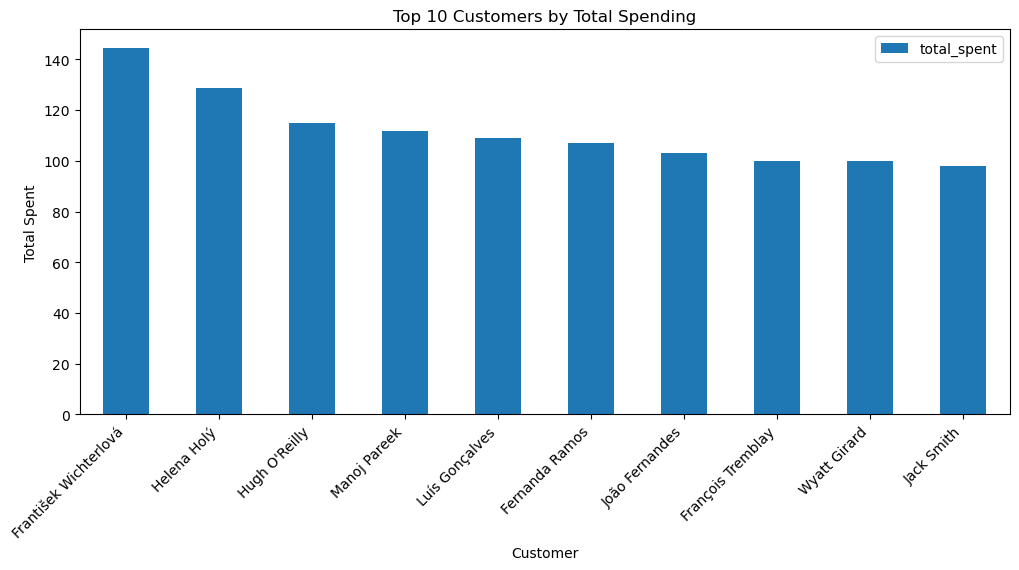

In [13]:
df3.plot(
    x="customer",
    y="total_spent",
    kind="bar",
    figsize=(12, 5),
    title="Top 10 Customers by Total Spending"
)

plt.xlabel("Customer")
plt.ylabel("Total Spent")
plt.xticks(rotation=45, ha="right")
plt.show()

In [14]:
query4 = """
SELECT 
    ar.name AS artist,
    SUM(il.unit_price * il.quantity) AS revenue
FROM artist ar
JOIN album al ON ar.artist_id = al.artist_id
JOIN track t ON al.album_id = t.album_id
JOIN invoice_line il ON t.track_id = il.track_id
GROUP BY ar.artist_id, ar.name
ORDER BY revenue DESC
LIMIT 5;
"""

df4 = pd.read_sql_query(query4, conn)

df4

,artist,revenue
0,Queen,190.08
1,Jimi Hendrix,185.13
2,Nirvana,128.70
3,Red Hot Chili Peppers,128.70
4,Pearl Jam,127.71


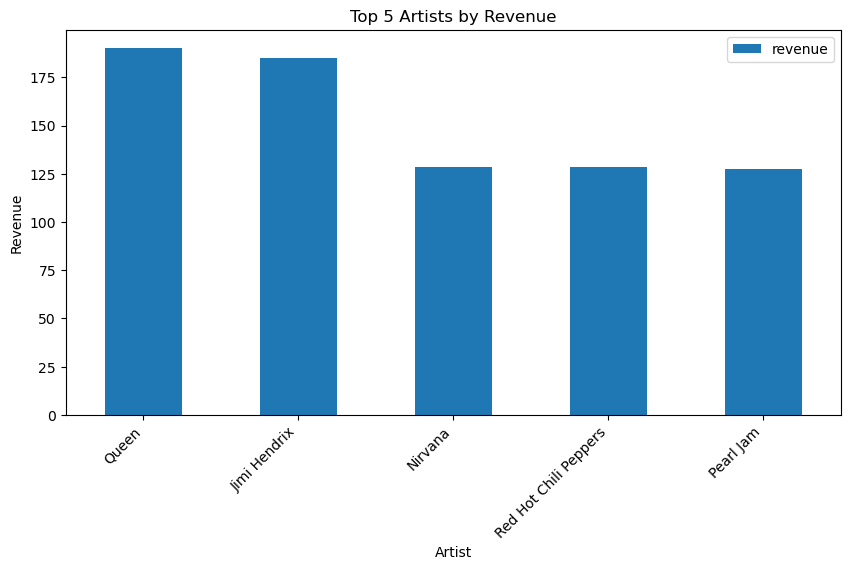

In [15]:
df4.plot(
    x="artist",
    y="revenue",
    kind="bar",
    figsize=(10, 5),
    title="Top 5 Artists by Revenue"
)

plt.xlabel("Artist")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.show()

In [16]:
query5 = """
SELECT 
    billing_country AS country,
    AVG(total) AS average_revenue
FROM invoice
GROUP BY billing_country
ORDER BY average_revenue DESC;
"""

df5 = pd.read_sql_query(query5, conn)

df5

,country,average_revenue
0,Czech Republic,9.108000
1,Spain,8.910000
2,Ireland,8.833846
3,United Kingdom,8.768571
4,India,8.721429
5,Belgium,8.627143
6,Germany,8.161463
7,Australia,8.118000
8,Norway,8.030000
9,USA,7.942672


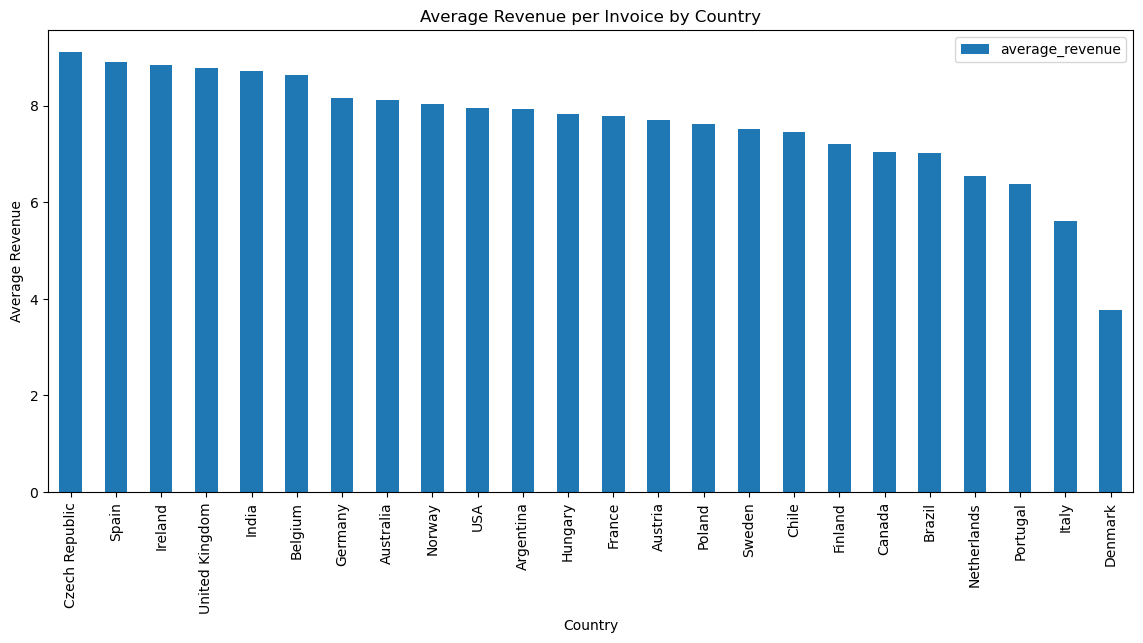

In [17]:
df5.plot(
    x="country",
    y="average_revenue",
    kind="bar",
    figsize=(14, 6),
    title="Average Revenue per Invoice by Country"
)

plt.xlabel("Country")
plt.ylabel("Average Revenue")
plt.xticks(rotation=90)
plt.show()

In [18]:
query6 = """
SELECT 
    m.name AS media_type,
    COUNT(t.track_id) AS track_count
FROM media_type m
JOIN track t ON m.media_type_id = t.media_type_id
GROUP BY m.media_type_id, m.name
ORDER BY track_count DESC;
"""

df6 = pd.read_sql_query(query6, conn)

df6

,media_type,track_count
0,MPEG audio file,3034
1,Protected AAC audio file,237
2,Protected MPEG-4 video file,214
3,AAC audio file,11
4,Purchased AAC audio file,7


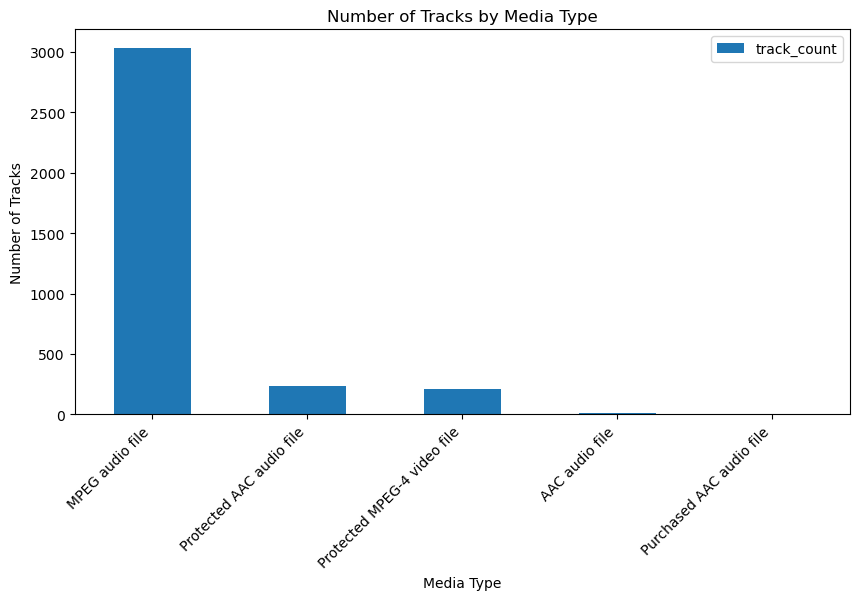

In [19]:
df6.plot(
    x="media_type",
    y="track_count",
    kind="bar",
    figsize=(10, 5),
    title="Number of Tracks by Media Type"
)

plt.xlabel("Media Type")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=45, ha="right")
plt.show()

In [20]:
query7 = """
SELECT 
    ar.name AS artist,
    COUNT(DISTINCT t.genre_id) AS genre_count
FROM artist ar
JOIN album al ON ar.artist_id = al.artist_id
JOIN track t ON al.album_id = t.album_id
GROUP BY ar.artist_id, ar.name
HAVING COUNT(DISTINCT t.genre_id) > 1
ORDER BY genre_count DESC;
"""

df7 = pd.read_sql_query(query7, conn)

df7

,artist,genre_count
0,Iron Maiden,4
1,Audioslave,3
2,Various Artists,3
3,Gilberto Gil,3
4,Jamiroquai,3
5,Lenny Kravitz,3
6,Battlestar Galactica,3
7,Antônio Carlos Jobim,2
8,Eric Clapton,2
9,Faith No More,2


In [22]:
query8 = """
SELECT 
    name AS track,
    ROUND(milliseconds / 60000.0, 2) AS duration_minutes
FROM track
ORDER BY milliseconds DESC
LIMIT 10;
"""

df8 = pd.read_sql_query(query8, conn)

df8

,track,duration_minutes
0,Occupation / Precipice,88.12
1,Through a Looking Glass,84.81
2,"Greetings from Earth, Pt. 1",49.34
3,The Man With Nine Lives,49.28
4,"Battlestar Galactica, Pt. 2",49.27
5,"Battlestar Galactica, Pt. 1",49.21
6,Murder On the Rising Star,48.93
7,"Battlestar Galactica, Pt. 3",48.80
8,Take the Celestra,48.79
9,Fire In Space,48.78


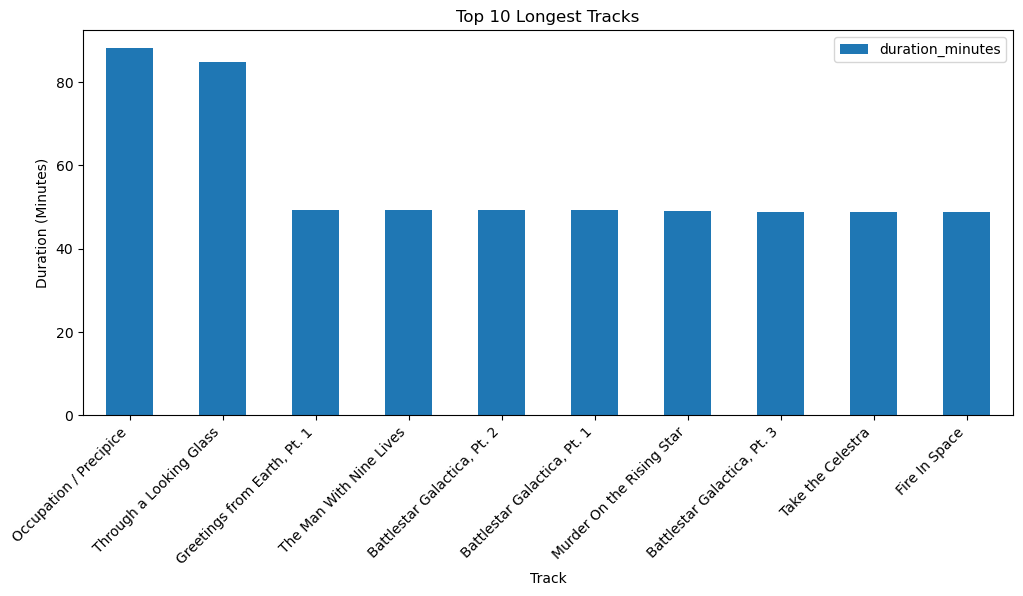

In [23]:
df8.plot(
    x="track",
    y="duration_minutes",
    kind="bar",
    figsize=(12, 5),
    title="Top 10 Longest Tracks"
)

plt.xlabel("Track")
plt.ylabel("Duration (Minutes)")
plt.xticks(rotation=45, ha="right")
plt.show()

In [24]:
query9 = """
WITH artist_revenue AS (
    SELECT 
        ar.artist_id,
        ar.name AS artist,
        SUM(il.unit_price * il.quantity) AS revenue
    FROM artist ar
    JOIN album al ON ar.artist_id = al.artist_id
    JOIN track t ON al.album_id = t.album_id
    JOIN invoice_line il ON t.track_id = il.track_id
    GROUP BY ar.artist_id, ar.name
),
total_revenue AS (
    SELECT SUM(revenue) AS total_revenue
    FROM artist_revenue
)
SELECT 
    artist,
    revenue,
    ROUND(revenue * 100.0 / total_revenue, 2) AS revenue_share
FROM artist_revenue, total_revenue
ORDER BY revenue DESC
LIMIT 5;
"""

df9 = pd.read_sql_query(query9, conn)

df9

,artist,revenue,revenue_share
0,Queen,190.08,4.04
1,Jimi Hendrix,185.13,3.93
2,Nirvana,128.70,2.73
3,Red Hot Chili Peppers,128.70,2.73
4,Pearl Jam,127.71,2.71


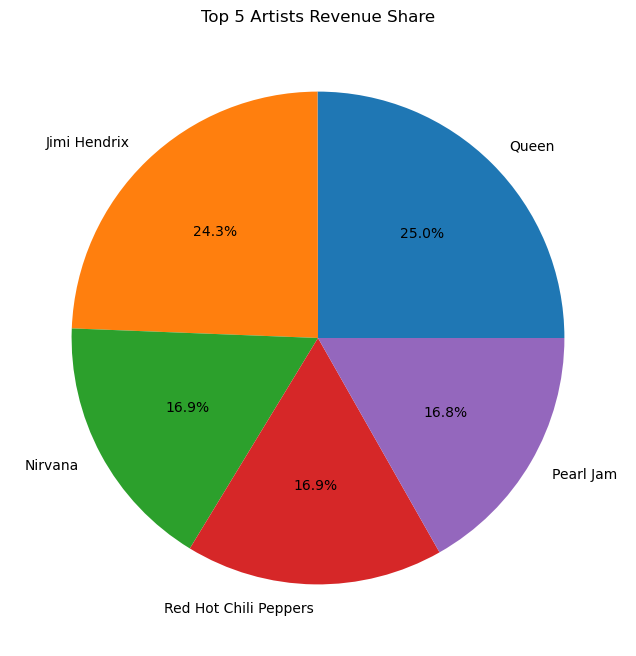

In [25]:
plt.figure(figsize=(8, 8))

plt.pie(
    df9["revenue_share"],
    labels=df9["artist"],
    autopct="%1.1f%%"
)

plt.title("Top 5 Artists Revenue Share")
plt.show()

In [26]:
query10 = """
SELECT 
    i.billing_country AS country,
    g.name AS genre,
    SUM(il.unit_price * il.quantity) AS revenue
FROM invoice i
JOIN invoice_line il ON i.invoice_id = il.invoice_id
JOIN track t ON il.track_id = t.track_id
JOIN genre g ON t.genre_id = g.genre_id
WHERE g.name IN ('Rock', 'Latin', 'Metal')
GROUP BY i.billing_country, g.name
ORDER BY i.billing_country, g.name;
"""

df10 = pd.read_sql_query(query10, conn)

df10

,country,genre,revenue
0,Argentina,Latin,1.98
1,Argentina,Metal,1.98
2,Argentina,Rock,10.89
3,Australia,Latin,1.98
4,Australia,Metal,13.86
...,...,...,...
65,USA,Metal,122.76
66,USA,Rock,555.39
67,United Kingdom,Latin,6.93
68,United Kingdom,Metal,30.69


In [27]:
pivot_df = df10.pivot(
    index="country",
    columns="genre",
    values="revenue"
).fillna(0)

pivot_df

genre,Latin,Metal,Rock
country,,,
Argentina,1.98,1.98,10.89
Australia,1.98,13.86,33.66
Austria,0.99,6.93,39.60
Belgium,1.98,18.81,25.74
Brazil,12.87,72.27,202.95
Canada,12.87,71.28,329.67
Chile,3.96,10.89,60.39
Czech Republic,20.79,22.77,141.57
Denmark,0.00,4.95,23.76


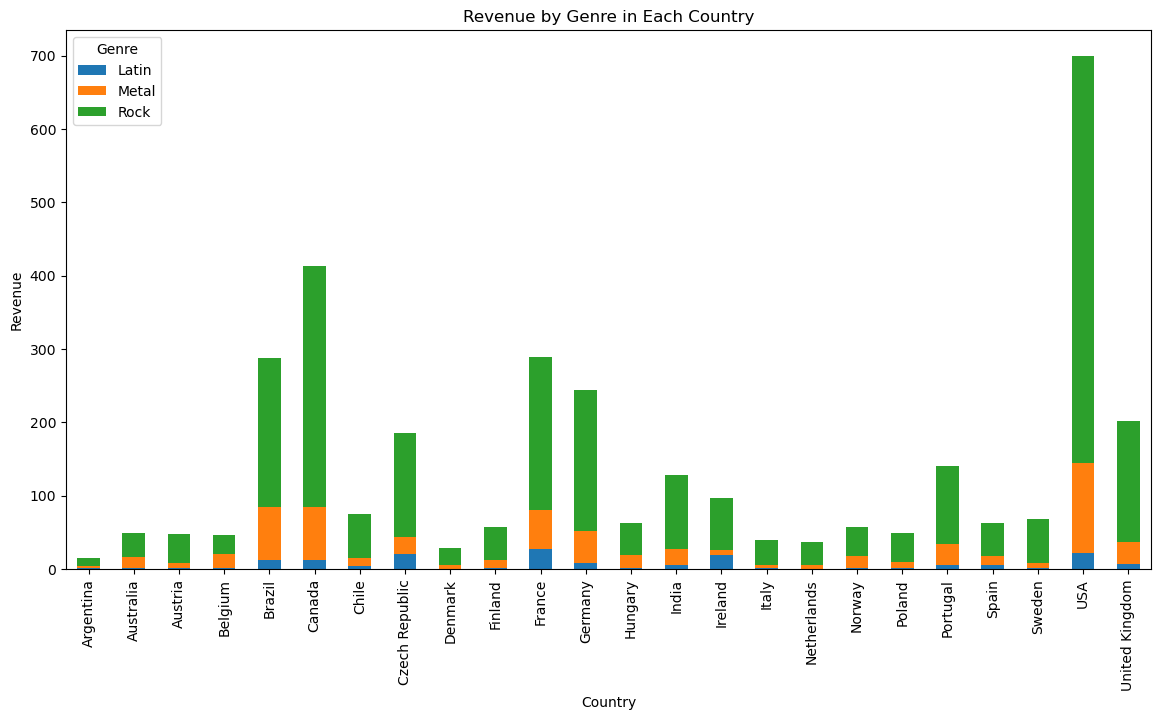

In [28]:
pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    title="Revenue by Genre in Each Country"
)

plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.legend(title="Genre")
plt.show()